# Ejercicio 2 — Clasificación de dígitos con un perceptrón multicapa

**Preguntas del enunciado:** (a) ¿cómo evaluamos el desempeño? (b) ¿qué variantes probamos para encontrar una solución? El conjunto `digits.csv` se utiliza para entrenamiento y selección; `digits_test.csv` se reserva para una única evaluación final. Este notebook presenta el experimento y deja las respuestas junto a los resultados.

**Nota sobre la implementación:** se consideran las arquitecturas, tasas de aprendizaje, optimizadores y criterio de selección previstos para el experimento. La comparación inicial usa 15 épocas sobre train/validación, mientras que el entrenamiento final usa 50 épocas sobre todo digits.csv. El entrenamiento se expresa con operaciones por minibatches para que la búsqueda completa se pueda ejecutar en un notebook; esto puede cambiar los valores numéricos frente a una ejecución muestra por muestra.

In [1]:
from pathlib import Path
import ast
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, log_loss
from sklearn.model_selection import train_test_split

os.environ.setdefault('OPENBLAS_NUM_THREADS', '2')
SEED = 42
rng = np.random.default_rng(SEED)
DATA_DIR = Path.cwd() / 'data' if (Path.cwd() / 'data' / 'digits.csv').exists() else Path.cwd() / 'TP3' / 'data'
assert (DATA_DIR / 'digits.csv').exists(), 'Abrir el notebook desde TP3 o desde la raíz del repositorio.'
FIG_DIR = DATA_DIR.parent / 'figures_ej2'
FIG_DIR.mkdir(exist_ok=True)


def show(name):
    """Guarda la figura actual en figures_ej2/ y la muestra."""
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()


print('Datos:', DATA_DIR.resolve())

Datos: C:\Users\maria\repos\DIAO2A\TP3\data


## 1. Datos y objetivo

Cada fila contiene una imagen de 28×28 píxeles y una etiqueta entre 0 y 9. Los valores de píxel ya están en `[0, 1]`. El modelo produce diez probabilidades mediante *softmax* y predice la clase con mayor probabilidad. Antes de entrenar, inspeccionamos las clases disponibles en cada archivo: esto es esencial para interpretar el resultado de test.

,digits.csv,digits_test.csv
Dígito,,
0,1480,245
1,1685,283
2,1489,258
3,1532,252
4,1460,245
5,271,223
6,1479,239
7,1566,257
8,0,243


Desarrollo: 12,449 imágenes | Test: 2,497 imágenes | Píxeles: 784


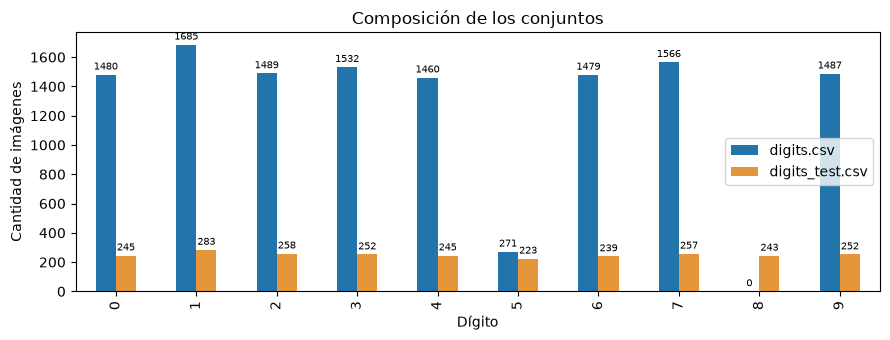

In [2]:
def load_digits(path):
    frame = pd.read_csv(path)
    images = np.stack(frame['image'].map(lambda text: np.asarray(ast.literal_eval(text), dtype=np.float32)))
    labels = frame['label'].to_numpy(dtype=np.int64)
    assert images.shape[1] == 784 and np.isfinite(images).all()
    assert images.min() >= 0 and images.max() <= 1
    return images, labels

X_dev, y_dev = load_digits(DATA_DIR / 'digits.csv')
X_test, y_test = load_digits(DATA_DIR / 'digits_test.csv')
counts = pd.DataFrame({
    'digits.csv': pd.Series(y_dev).value_counts().reindex(range(10), fill_value=0),
    'digits_test.csv': pd.Series(y_test).value_counts().reindex(range(10), fill_value=0),
})
counts.index.name = 'Dígito'
display(counts)
print(f'Desarrollo: {len(y_dev):,} imágenes | Test: {len(y_test):,} imágenes | Píxeles: {X_dev.shape[1]}')
ax = counts.plot.bar(figsize=(9, 3.5), color=['#2374AB', '#E5953A'])
for container in ax.containers:
    ax.bar_label(container, fontsize=7, padding=2)
ax.set(ylabel='Cantidad de imágenes', title='Composición de los conjuntos')
plt.tight_layout()
show('distribucion_clases_ej2')

**Hallazgo relevante:** `digits.csv` no contiene ejemplos etiquetados como 8 y tiene muchos menos ejemplos de 5 que de otras clases. `digits_test.csv` sí contiene todas las clases. Esto limita lo que puede aprenderse en el ejercicio 2 y sirve para interpretar la mejora potencial del ejercicio 3, que incorpora más datos. No incorporamos `more_digits.csv` aquí porque corresponde al ejercicio 3.

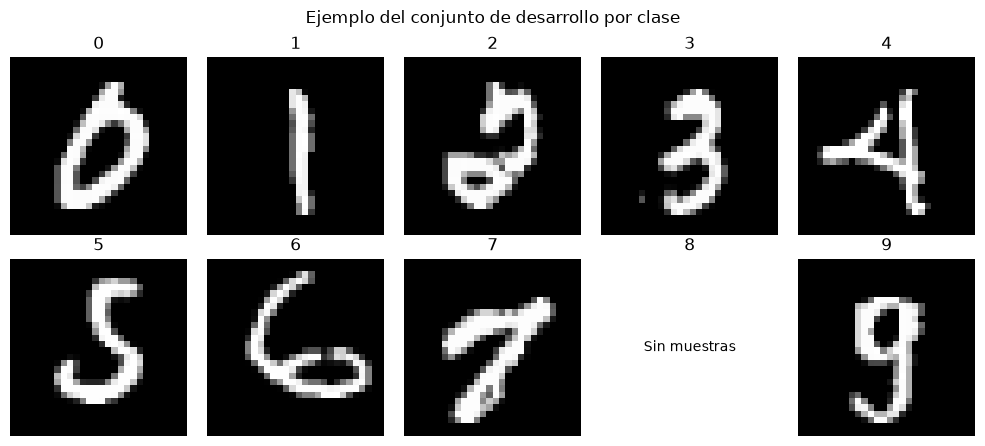

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in enumerate(axes.flat):
    matches = np.flatnonzero(y_dev == digit)
    if len(matches):
        ax.imshow(X_dev[matches[0]].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    else:
        ax.text(.5, .5, 'Sin muestras', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(str(digit))
    ax.axis('off')
plt.suptitle('Ejemplo del conjunto de desarrollo por clase')
plt.tight_layout()
show('ejemplos_digitos_ej2')

## 2. ¿Cómo evaluamos el desempeño?

- **Accuracy:** proporción total de dígitos clasificados correctamente. Es el criterio usado para seleccionar configuraciones.
- **Precision macro:** promedio de la precision de cada dígito; pregunta qué proporción de las predicciones de cada clase fue correcta.
- **Recall macro:** promedio de la fracción detectada de cada dígito real.
- **F1 macro:** promedio del F1 de cada clase, donde $F1=2PR/(P+R)$. Da el mismo peso a todas las clases, aunque tengan distinta cantidad de ejemplos.
- **Matriz de confusión:** muestra qué pares de dígitos se confunden. El *support* del informe por clase indica cuántos casos reales hay.

La pérdida (*cross-entropy*) permite estudiar el aprendizaje por época; **el criterio para elegir hiperparámetros sigue siendo accuracy de validación**. Las métricas de test se calculan una sola vez después de fijar la configuración.

## 3. Partición y variantes

Separamos `digits.csv` en 80 % entrenamiento y 20 % validación mediante una partición estratificada con semilla 42. Probamos **3 arquitecturas × 3 tasas × 4 optimizadores = 36 configuraciones**. Cada configuración comienza con la misma semilla para que la comparación sea reproducible. Usamos 15 épocas en la búsqueda y minibatches de 256 ejemplos. La validación no actualiza pesos.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=SEED
)
print(f'Train: {len(y_train):,} | Validación: {len(y_val):,} | Test reservado: {len(y_test):,}')
print('Clases de entrenamiento:', np.unique(y_train).tolist())

ARCHITECTURES = [(32, 16), (64, 32), (128, 64)]
LEARNING_RATES = [0.1, 0.01, 0.001]
OPTIMIZERS = ['sgd', 'momentum', 'rmsprop', 'adam']
SEARCH_EPOCHS = 15
FINAL_EPOCHS = 50
BATCH_SIZE = 256

Train: 9,959 | Validación: 2,490 | Test reservado: 2,497
Clases de entrenamiento: [0, 1, 2, 3, 4, 5, 6, 7, 9]


### Red multicapa y entrenamiento

La versión siguiente conserva la estructura de `MLP2`: dos capas ocultas ReLU, salida softmax, pérdida de entropía cruzada y SGD, momentum, RMSProp o Adam. Las multiplicaciones y los gradientes se calculan por minibatch. La misma clase permite usar una capa oculta en la comparación inicial. Los pesos se inicializan con una semilla explícita.

In [5]:
class DigitMLP:
    def __init__(self, hidden, lr=0.01, optimizer='sgd', activation='relu', seed=42):
        self.hidden = tuple(hidden)
        self.lr, self.optimizer, self.activation = lr, optimizer, activation
        gen = np.random.default_rng(seed)
        sizes = (784, *self.hidden, 10)
        self.weights = [gen.normal(0, np.sqrt(2 / a if activation == 'relu' else 1 / a), (a, b)).astype(np.float32)
                        for a, b in zip(sizes[:-1], sizes[1:])]
        self.biases = [np.zeros((1, b), dtype=np.float32) for b in sizes[1:]]
        self.params = [p for pair in zip(self.weights, self.biases) for p in pair]
        self.m = [np.zeros_like(p) for p in self.params]
        self.v = [np.zeros_like(p) for p in self.params]
        self.t = 0

    def _activate(self, z):
        return np.maximum(z, 0) if self.activation == 'relu' else 1 / (1 + np.exp(-np.clip(z, -40, 40)))

    def forward(self, X, cache=False):
        a = X
        activations, preactivations = [a], []
        for w, b in zip(self.weights[:-1], self.biases[:-1]):
            z = a @ w + b
            a = self._activate(z)
            preactivations.append(z)
            activations.append(a)
        logits = a @ self.weights[-1] + self.biases[-1]
        shifted = logits - logits.max(axis=1, keepdims=True)
        exps = np.exp(shifted)
        probs = exps / exps.sum(axis=1, keepdims=True)
        return (probs, activations, preactivations) if cache else probs

    def predict(self, X, batch_size=1024):
        return np.concatenate([self.forward(X[i:i + batch_size]).argmax(axis=1)
                               for i in range(0, len(X), batch_size)])

    def train_batch(self, X, y):
        probs, activations, preactivations = self.forward(X, cache=True)
        loss = -np.log(np.maximum(probs[np.arange(len(y)), y], 1e-12)).mean()
        delta = probs.copy()
        delta[np.arange(len(y)), y] -= 1
        delta /= len(y)
        grads_w, grads_b = [None] * len(self.weights), [None] * len(self.weights)
        for layer in range(len(self.weights) - 1, -1, -1):
            grads_w[layer] = activations[layer].T @ delta
            grads_b[layer] = delta.sum(axis=0, keepdims=True)
            if layer:
                delta = delta @ self.weights[layer].T
                z = preactivations[layer - 1]
                if self.activation == 'relu':
                    delta *= (z > 0)
                else:
                    a = activations[layer]
                    delta *= a * (1 - a)
        grads = [g for pair in zip(grads_w, grads_b) for g in pair]
        self.t += 1
        for i, (p, g) in enumerate(zip(self.params, grads)):
            if self.optimizer == 'sgd':
                p -= self.lr * g
            elif self.optimizer == 'momentum':
                self.m[i] = 0.9 * self.m[i] + g
                p -= self.lr * self.m[i]
            elif self.optimizer == 'rmsprop':
                self.v[i] = 0.999 * self.v[i] + 0.001 * g * g
                p -= self.lr * g / (np.sqrt(self.v[i]) + 1e-8)
            elif self.optimizer == 'adam':
                self.m[i] = 0.9 * self.m[i] + 0.1 * g
                self.v[i] = 0.999 * self.v[i] + 0.001 * g * g
                m_hat = self.m[i] / (1 - 0.9 ** self.t)
                v_hat = self.v[i] / (1 - 0.999 ** self.t)
                p -= self.lr * m_hat / (np.sqrt(v_hat) + 1e-8)
            else:
                raise ValueError(self.optimizer)
        return float(loss)


def fit(model, X, y, epochs, seed=42, batch_size=256, X_val=None, y_val=None):
    gen = np.random.default_rng(seed)
    history = []
    for epoch in range(epochs):
        order = gen.permutation(len(y))
        losses = []
        for start in range(0, len(y), batch_size):
            batch = order[start:start + batch_size]
            losses.append(model.train_batch(X[batch], y[batch]))
        row = {'epoch': epoch + 1, 'train_loss': float(np.mean(losses))}
        if X_val is not None:
            row['val_accuracy'] = accuracy_score(y_val, model.predict(X_val))
        history.append(row)
    return pd.DataFrame(history)

## 4. Comparación inicial de arquitecturas

Evaluamos una red de una capa oculta de 32 neuronas y otra de dos capas (64, 32). Comparamos ambas en **validación**, de forma que la tabla no confunda ajuste de entrenamiento con generalización. Esta comparación es descriptiva; la selección sistemática se hace en la grilla siguiente.

,Modelo,Accuracy validación,Pérdida final de entrenamiento
0,MLP (32),0.747390,1.755022
1,"MLP2 (64,32)",0.898795,0.406623


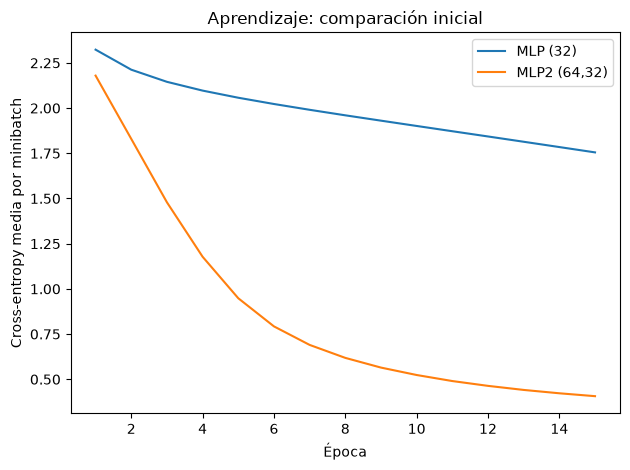

In [6]:
baseline_rows = []
baseline_histories = {}
for name, hidden, activation in [('MLP (32)', (32,), 'sigmoid'), ('MLP2 (64,32)', (64, 32), 'relu')]:
    model = DigitMLP(hidden, lr=0.01, optimizer='sgd', activation=activation, seed=SEED)
    history = fit(model, X_train, y_train, 15, X_val=X_val, y_val=y_val)
    baseline_histories[name] = history
    baseline_rows.append({'Modelo': name, 'Accuracy validación': accuracy_score(y_val, model.predict(X_val)),
                          'Pérdida final de entrenamiento': history.train_loss.iloc[-1]})
display(pd.DataFrame(baseline_rows))
for name, history in baseline_histories.items():
    plt.plot(history.epoch, history.train_loss, label=name)
plt.xlabel('Época'); plt.ylabel('Cross-entropy media por minibatch')
plt.title('Aprendizaje: comparación inicial'); plt.legend(); plt.tight_layout(); show('comparacion_inicial_ej2')

## 5. Búsqueda de hiperparámetros

Cada fila de la tabla siguiente es un entrenamiento independiente de 15 épocas. **Seleccionamos por accuracy de validación**; en caso de empate, mantenemos el primer resultado según el orden de la grilla. El test permanece sin consultar.

In [7]:
search_rows = []
search_histories = {}
started = time.perf_counter()
for hidden in ARCHITECTURES:
    for lr in LEARNING_RATES:
        for optimizer in OPTIMIZERS:
            model = DigitMLP(hidden, lr=lr, optimizer=optimizer, seed=SEED)
            history = fit(model, X_train, y_train, SEARCH_EPOCHS, X_val=X_val, y_val=y_val)
            key = (hidden, lr, optimizer)
            search_histories[key] = history
            pred = model.predict(X_val)
            report = classification_report(y_val, pred, labels=range(10), output_dict=True, zero_division=0)
            search_rows.append({'Arquitectura': str(hidden), 'LR': lr, 'Optimizador': optimizer,
                                'Accuracy validación': accuracy_score(y_val, pred),
                                'F1 macro validación': report['macro avg']['f1-score'],
                                'Pérdida train': history.train_loss.iloc[-1], 'key': key})
            print(f'{hidden} | lr={lr:g} | {optimizer:8s} | accuracy val={search_rows[-1]["Accuracy validación"]:.4f}')
search_results = pd.DataFrame(search_rows)
ranking = search_results.sort_values('Accuracy validación', ascending=False, kind='stable').reset_index(drop=True)
best = ranking.iloc[0]
best_hidden, best_lr, best_optimizer = best['key']
print(f'Búsqueda completada en {(time.perf_counter() - started) / 60:.1f} min')
display(ranking.drop(columns='key').head(12).style.format({'Accuracy validación': '{:.4f}', 'F1 macro validación': '{:.4f}', 'Pérdida train': '{:.4f}'}))
print('Configuración elegida:', best_hidden, best_lr, best_optimizer)

(32, 16) | lr=0.1 | sgd      | accuracy val=0.9353


(32, 16) | lr=0.1 | momentum | accuracy val=0.9582


(32, 16) | lr=0.1 | rmsprop  | accuracy val=0.1353


(32, 16) | lr=0.1 | adam     | accuracy val=0.8964


(32, 16) | lr=0.01 | sgd      | accuracy val=0.8767


...

(128, 64) | lr=0.001 | momentum | accuracy val=0.9020


(128, 64) | lr=0.001 | rmsprop  | accuracy val=0.9643


(128, 64) | lr=0.001 | adam     | accuracy val=0.9651
Búsqueda completada en 0.7 min


,Arquitectura,LR,Optimizador,Accuracy validación,F1 macro validación,Pérdida train
0,"(128, 64)",0.100000,momentum,0.9675,0.8622,0.0051
1,"(128, 64)",0.001000,adam,0.9651,0.8579,0.0346
2,"(128, 64)",0.010000,adam,0.9643,0.8603,0.0439
3,"(128, 64)",0.001000,rmsprop,0.9643,0.8586,0.0183
4,"(64, 32)",0.100000,momentum,0.9639,0.8552,0.0141
5,"(64, 32)",0.010000,adam,0.9610,0.8598,0.0089
6,"(64, 32)",0.001000,rmsprop,0.9602,0.8556,0.0450
7,"(64, 32)",0.001000,adam,0.9586,0.8486,0.0799
8,"(32, 16)",0.100000,momentum,0.9582,0.8541,0.0438
9,"(32, 16)",0.001000,adam,0.9518,0.8453,0.1117


Configuración elegida: (128, 64) 0.1 momentum


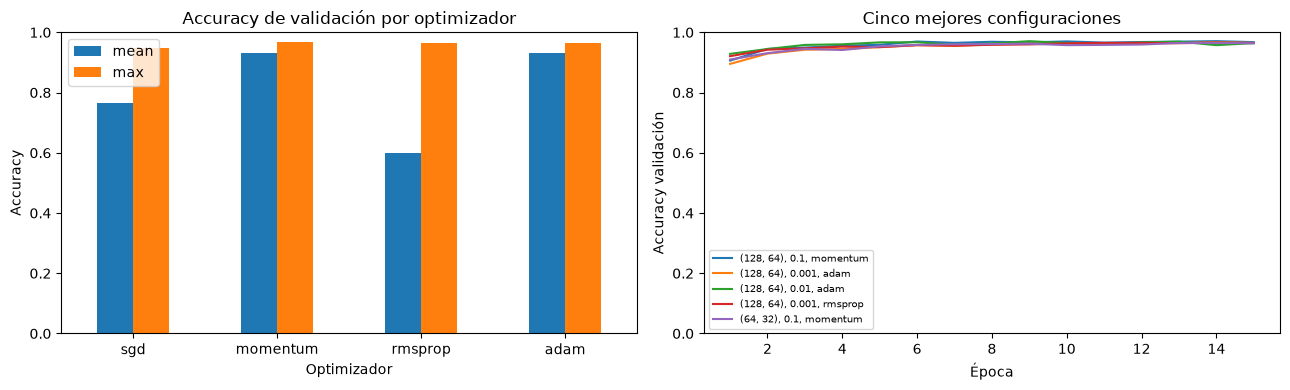

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary = search_results.groupby('Optimizador')['Accuracy validación'].agg(['mean', 'max']).reindex(OPTIMIZERS)
summary.plot.bar(ax=axes[0], rot=0)
axes[0].set(title='Accuracy de validación por optimizador', ylabel='Accuracy', ylim=(0, 1))
for _, row in ranking.head(5).iterrows():
    h = search_histories[row['key']]
    axes[1].plot(h.epoch, h.val_accuracy, label=f'{row["Arquitectura"]}, {row["LR"]:g}, {row["Optimizador"]}')
axes[1].set(title='Cinco mejores configuraciones', xlabel='Época', ylabel='Accuracy validación', ylim=(0, 1))
axes[1].legend(fontsize=7)
plt.tight_layout(); show('busqueda_grid_ej2')

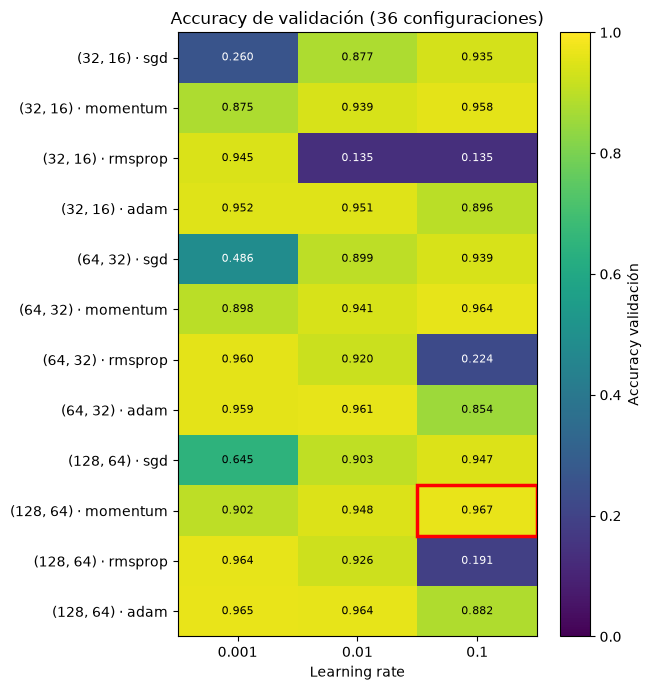

In [9]:
grid = search_results.pivot_table(index=['Arquitectura', 'Optimizador'], columns='LR',
                                  values='Accuracy validación', sort=False)
grid = grid[sorted(grid.columns)]
fig, ax = plt.subplots(figsize=(6.5, 7))
im = ax.imshow(grid.to_numpy(), cmap='viridis', vmin=0, vmax=1, aspect='auto')
for (r, col), value in np.ndenumerate(grid.to_numpy()):
    ax.text(col, r, f'{value:.3f}', ha='center', va='center', fontsize=8,
            color='black' if value > 0.6 else 'white')
r = grid.index.get_loc((best['Arquitectura'], best_optimizer))
col = list(grid.columns).index(best_lr)
ax.add_patch(plt.Rectangle((col - 0.5, r - 0.5), 1, 1, fill=False, edgecolor='red', lw=2.5))
ax.set_xticks(range(len(grid.columns)), [f'{lr:g}' for lr in grid.columns])
ax.set_yticks(range(len(grid.index)), [f'{arch} · {opt}' for arch, opt in grid.index])
ax.set(xlabel='Learning rate', title=f'Accuracy de validación ({len(search_results)} configuraciones)')
fig.colorbar(im, ax=ax, label='Accuracy validación')
plt.tight_layout(); show('heatmap_grid_search_ej2')

El recuadro rojo marca la configuración elegida. La grilla muestra dos efectos de la tasa de aprendizaje: con lr = 0,1 los optimizadores adaptativos (RMSProp y, en menor medida, Adam) se vuelven inestables, mientras que SGD sin momentum con lr = 0,001 no llega a converger en 15 épocas. La arquitectura influye menos que la combinación optimizador–tasa.

## 6. Modelo elegido y evaluación final

Reentrenamos desde cero la configuración elegida con todo `digits.csv` durante 50 épocas. El cambio de 15 a 50 épocas puede alterar la generalización. No ajustamos nada después de observar el test.

In [10]:
final_model = DigitMLP(best_hidden, lr=best_lr, optimizer=best_optimizer, seed=SEED)
final_history = fit(final_model, X_dev, y_dev, FINAL_EPOCHS)
pred_train = final_model.predict(X_dev)
pred_test = final_model.predict(X_test)
test_report = classification_report(y_test, pred_test, labels=range(10), output_dict=True, zero_division=0)
final_summary = pd.DataFrame([
    {'Conjunto': 'Entrenamiento completo', 'Accuracy': accuracy_score(y_dev, pred_train),
     'F1 macro': classification_report(y_dev, pred_train, labels=range(10), output_dict=True, zero_division=0)['macro avg']['f1-score']},
    {'Conjunto': 'Test reservado', 'Accuracy': accuracy_score(y_test, pred_test),
     'F1 macro': test_report['macro avg']['f1-score']},
])
display(final_summary)
display(pd.DataFrame(test_report).T.loc[[str(i) for i in range(10)], ['precision', 'recall', 'f1-score', 'support']])
print('Configuración:', best_hidden, '| learning rate:', best_lr, '| optimizador:', best_optimizer,
      '| épocas finales:', FINAL_EPOCHS)

,Conjunto,Accuracy,F1 macro
0,Entrenamiento completo,1.000000,0.900000
1,Test reservado,0.866239,0.819768


,precision,recall,f1-score,support
0,0.906716,0.991837,0.947368,245.0
1,0.952381,0.989399,0.970537,283.0
2,0.908088,0.957364,0.932075,258.0
3,0.705382,0.988095,0.823140,252.0
4,0.933071,0.967347,0.949900,245.0
5,0.757937,0.856502,0.804211,223.0
6,0.885496,0.970711,0.926148,239.0
7,0.968504,0.957198,0.962818,257.0
8,0.000000,0.000000,0.000000,243.0
9,0.826389,0.944444,0.881481,252.0


Configuración: (128, 64) | learning rate: 0.1 | optimizador: momentum | épocas finales: 50


In [11]:
acc_train = accuracy_score(y_dev, pred_train)
acc_test = accuracy_score(y_test, pred_test)
is_8 = y_test == 8
hits_8 = int((pred_test[is_8] == 8).sum())
hits_rest = int((pred_test[~is_8] == y_test[~is_8]).sum())
lost_by_8 = (is_8.sum() - hits_8) / len(y_test)
gap = acc_train - acc_test
es = lambda text: text.replace(',', ' ').replace('.', ',').replace(' ', '.')
display(Markdown(
    f'**Lectura de la diferencia entre validación y test.** La validación solo contiene clases presentes en digits.csv, '
    f'mientras que test incluye {is_8.sum()} imágenes del 8. El modelo acertó {hits_8} de esos {is_8.sum()} casos. '
    f'Sobre las otras nueve clases acertó {es(f'{hits_rest:,}')} de {es(f'{(~is_8).sum():,}')} (**{es(f'{hits_rest / (~is_8).sum():.2%}')}**); '
    f'al incluir los ochos, la accuracy total baja a **{es(f'{acc_test:.2%}')}**. '
    f'La brecha train → test es {es(f'{gap:.4f}')} y los ochos explican {es(f'{lost_by_8:.4f}')} de ella '
    f'(**{lost_by_8 / gap:.0%}**). Esto no demuestra un error de partición: expone una limitación concreta del '
    f'conjunto de entrenamiento inicial. El F1 macro de entrenamiento aparece como 0,90 incluso con accuracy 1,00 '
    f'porque se promedian diez clases y la clase 8 ausente recibe F1 = 0.'
))

**Lectura de la diferencia entre validación y test.** La validación solo contiene clases presentes en digits.csv, mientras que test incluye 243 imágenes del 8. El modelo acertó 0 de esos 243 casos. Sobre las otras nueve clases acertó 2.163 de 2.254 (**95,96%**); al incluir los ochos, la accuracy total baja a **86,62%**. La brecha train → test es 0,1338 y los ochos explican 0,0973 de ella (**73%**). Esto no demuestra un error de partición: expone una limitación concreta del conjunto de entrenamiento inicial. El F1 macro de entrenamiento aparece como 0,90 incluso con accuracy 1,00 porque se promedian diez clases y la clase 8 ausente recibe F1 = 0.

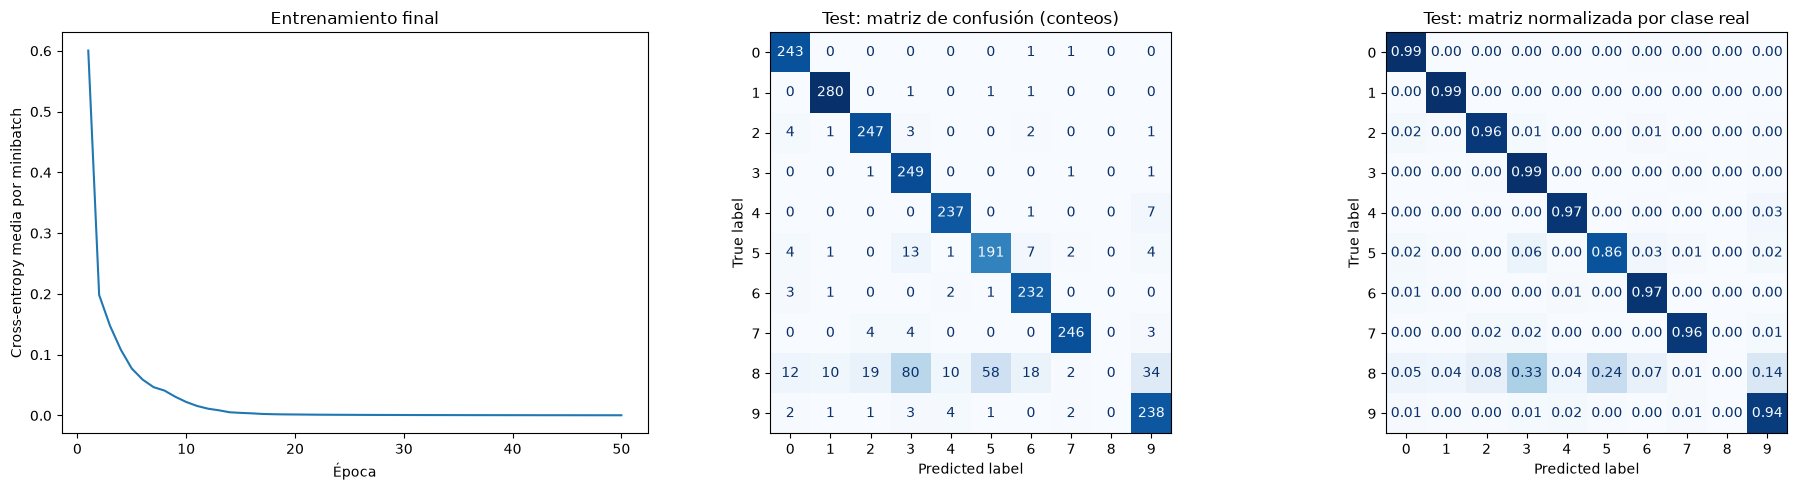

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].plot(final_history.epoch, final_history.train_loss)
axes[0].set(title='Entrenamiento final', xlabel='Época', ylabel='Cross-entropy media por minibatch')
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=range(10), cmap='Blues',
                                         ax=axes[1], colorbar=False)
axes[1].set_title('Test: matriz de confusión (conteos)')
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, labels=range(10), normalize='true',
                                         values_format='.2f', cmap='Blues', ax=axes[2], colorbar=False)
axes[2].set_title('Test: matriz normalizada por clase real')
plt.tight_layout(); show('evaluacion_test_ej2')

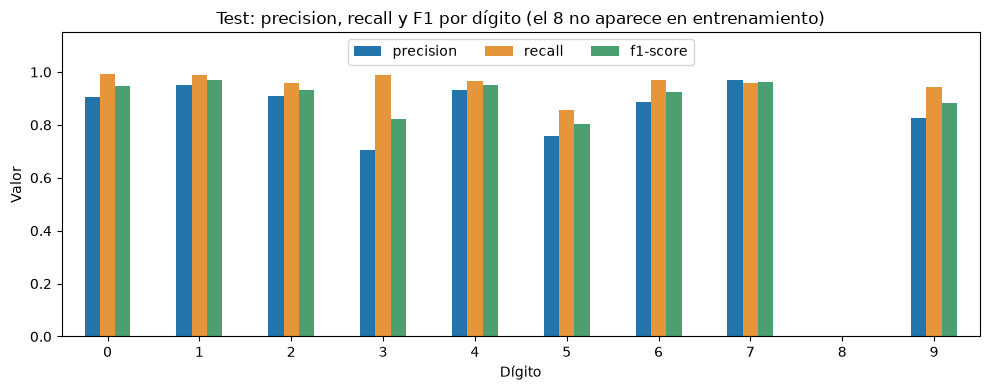

In [13]:
per_class = pd.DataFrame(test_report).T.loc[[str(i) for i in range(10)], ['precision', 'recall', 'f1-score']]
per_class.index.name = 'Dígito'
ax = per_class.plot.bar(figsize=(10, 4), rot=0, color=['#2374AB', '#E5953A', '#4C9F70'])
ax.set(title='Test: precision, recall y F1 por dígito (el 8 no aparece en entrenamiento)',
       ylabel='Valor', ylim=(0, 1.15))
ax.legend(loc='upper center', ncol=3)
plt.tight_layout(); show('metricas_por_clase_ej2')

### ¿Qué hace el modelo con los 8?

Como el modelo nunca vio un 8, cada 8 de test tiene que ir a alguna de las otras nueve clases. La distribución de esas predicciones y algunos ejemplos por clase predicha muestran a qué dígitos se parecen para la red.

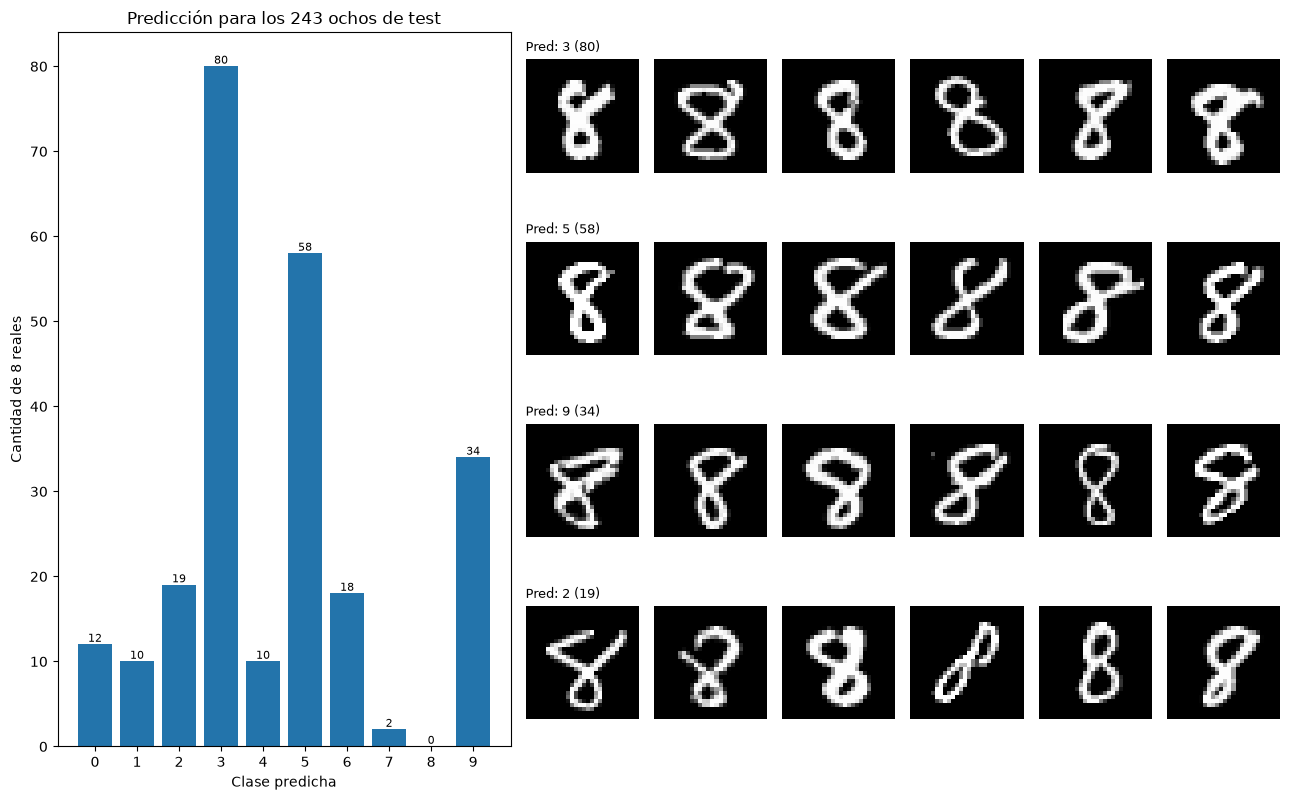

In [14]:
idx_8 = np.flatnonzero(y_test == 8)
dest = pd.Series(pred_test[idx_8]).value_counts().reindex(range(10), fill_value=0)
top_dest = [d for d in dest.sort_values(ascending=False).index if dest[d] > 0][:4]
n_examples = 6

fig = plt.figure(figsize=(13, 1.9 * len(top_dest) + 0.5))
grid_spec = fig.add_gridspec(len(top_dest), 1 + n_examples, width_ratios=[4] + [1] * n_examples)
ax = fig.add_subplot(grid_spec[:, 0])
ax.bar(dest.index, dest.values, color='#2374AB')
ax.bar_label(ax.containers[0], fontsize=8)
ax.set(xticks=range(10), xlabel='Clase predicha', ylabel='Cantidad de 8 reales',
       title=f'Predicción para los {len(idx_8)} ochos de test')
for row, digit in enumerate(top_dest):
    samples = idx_8[pred_test[idx_8] == digit][:n_examples]
    for j in range(n_examples):
        ax = fig.add_subplot(grid_spec[row, 1 + j])
        ax.axis('off')
        if j < len(samples):
            ax.imshow(X_test[samples[j]].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        if j == 0:
            ax.set_title(f'Pred: {digit} ({dest[digit]})', fontsize=9, loc='left')
plt.tight_layout(); show('ochos_test_ej2')

In [15]:
top_class = pd.DataFrame(test_report).T.loc[[str(i) for i in range(10)], ['precision', 'recall', 'f1-score', 'support']]
worst = top_class.sort_values('recall').head(3)
display(Markdown(
    f'## 7. Respuestas al enunciado\n\n'
    f'**(a) ¿Cómo evaluamos el desempeño?** Con accuracy, precision/recall/F1 macro y matriz de confusión. '
    f'La selección se hizo con accuracy de validación; el resultado final reservado es '
    f'**accuracy = {accuracy_score(y_test, pred_test):.4f}** y **F1 macro = {test_report["macro avg"]["f1-score"]:.4f}** en test. '
    f'Las tres clases con menor recall en test fueron {", ".join(worst.index)}.\n\n'
    f'**(b) ¿Qué variantes probamos?** Tres arquitecturas, tres tasas de aprendizaje y cuatro optimizadores '
    f'(36 configuraciones). Ganó **{best_hidden}, lr={best_lr:g}, {best_optimizer}** con '
    f'accuracy de validación **{best["Accuracy validación"]:.4f}**. Luego se entrenó esa configuración '
    f'desde cero con todas las imágenes de desarrollo.\n\n'
    f'**Interpretación:** estos números describen el conjunto de test provisto. La clase 8 no aparece en entrenamiento, '
    f'así que su resultado por clase debe leerse como una limitación de los datos iniciales. '
    f'No se puede afirmar robustez frente a otros datos o ruido sin nuevos experimentos.'
))

## 7. Respuestas al enunciado

**(a) ¿Cómo evaluamos el desempeño?** Con accuracy, precision/recall/F1 macro y matriz de confusión. La selección se hizo con accuracy de validación; el resultado final reservado es **accuracy = 0.8662** y **F1 macro = 0.8198** en test. Las tres clases con menor recall en test fueron 8, 5, 9.

**(b) ¿Qué variantes probamos?** Tres arquitecturas, tres tasas de aprendizaje y cuatro optimizadores (36 configuraciones). Ganó **(128, 64), lr=0.1, momentum** con accuracy de validación **0.9675**. Luego se entrenó esa configuración desde cero con todas las imágenes de desarrollo.

**Interpretación:** estos números describen el conjunto de test provisto. La clase 8 no aparece en entrenamiento, así que su resultado por clase debe leerse como una limitación de los datos iniciales. No se puede afirmar robustez frente a otros datos o ruido sin nuevos experimentos.

### Límites del experimento

El conjunto de desarrollo no cubre las diez clases y está desbalanceado. La búsqueda usa una sola partición y una sola inicialización por configuración, por lo que el ranking puede variar con otra semilla. El modelo final usa más épocas que los modelos comparados durante la búsqueda. Las métricas de test muestran desempeño sobre el archivo provisto; el ejercicio 3 estudia los datos adicionales por separado.